## Name: Pranav Sonawane
## PRN: 2125UMLM1039
## UNIT I: Introduction to Statistics

Statistics is a branch of mathematics dealing with the collection, analysis, interpretation, presentation, and organization of data. It helps in making informed decisions and understanding patterns within data.

### Descriptive Statistics

Descriptive statistics summarize and describe the main features of a collection of information. It uses measures like mean, median, mode, standard deviation, and variance to describe data.

In [1]:
import pandas as pd
import numpy as np

# Sample data: Student scores
student_scores = {
    'Student': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Math_Score': [85, 92, 78, 88, 95, 70, 82, 90, 75, 80],
    'Science_Score': [90, 88, 80, 92, 90, 75, 85, 93, 70, 82]
}
df_scores = pd.DataFrame(student_scores)

print("Original Data:\n", df_scores)

# Calculate descriptive statistics for Math_Score
print("\nDescriptive Statistics for Math_Score:")
print(df_scores['Math_Score'].describe())

# Calculate mode (can be multiple)
print("\nMode of Math_Score:", df_scores['Math_Score'].mode().tolist())

# Calculate variance
print("\nVariance of Math_Score:", df_scores['Math_Score'].var())

Original Data:
    Student  Math_Score  Science_Score
0    Alice          85             90
1      Bob          92             88
2  Charlie          78             80
3    David          88             92
4      Eve          95             90
5    Frank          70             75
6    Grace          82             85
7    Heidi          90             93
8     Ivan          75             70
9     Judy          80             82

Descriptive Statistics for Math_Score:
count    10.000000
mean     83.500000
std       7.947746
min      70.000000
25%      78.500000
50%      83.500000
75%      89.500000
max      95.000000
Name: Math_Score, dtype: float64

Mode of Math_Score: [70, 75, 78, 80, 82, 85, 88, 90, 92, 95]

Variance of Math_Score: 63.166666666666664


### Inferential Statistics

Inferential statistics makes inferences about a population using data drawn from the population. Instead of using the entire population to gather the data, the statistician will collect a sample or samples from the population and make inferences.

### Sampling Techniques

Sampling is the process of selecting a subset of individuals from a population to estimate characteristics of the whole population. Common techniques include simple random sampling, stratified sampling, and systematic sampling.

In [2]:
# Simple Random Sampling
population = list(range(1, 101)) # A population of 100 individuals
sample_size = 10

# Using numpy to randomly select a sample
random_sample = np.random.choice(population, size=sample_size, replace=False)
print(f"\nPopulation: {population[:5]}...{population[-5:]}") # Showing a snippet of the population
print(f"Random Sample (size={sample_size}): {random_sample}")

# Another example using the student scores dataframe
sample_students = df_scores.sample(n=3, random_state=42) # random_state for reproducibility
print("\nRandom Sample of 3 Students:\n", sample_students)


Population: [1, 2, 3, 4, 5]...[96, 97, 98, 99, 100]
Random Sample (size=10): [ 4 26 56 67 62  9 90 59 43 97]

Random Sample of 3 Students:
   Student  Math_Score  Science_Score
8    Ivan          75             70
1     Bob          92             88
5   Frank          70             75


### Correlation

Correlation measures the strength and direction of a linear relationship between two quantitative variables. The correlation coefficient (Pearson's r) ranges from -1 to +1, where +1 indicates a perfect positive linear relationship, -1 indicates a perfect negative linear relationship, and 0 indicates no linear relationship.


Correlation Matrix:
                Math_Score  Science_Score
Math_Score       1.000000       0.865662
Science_Score    0.865662       1.000000


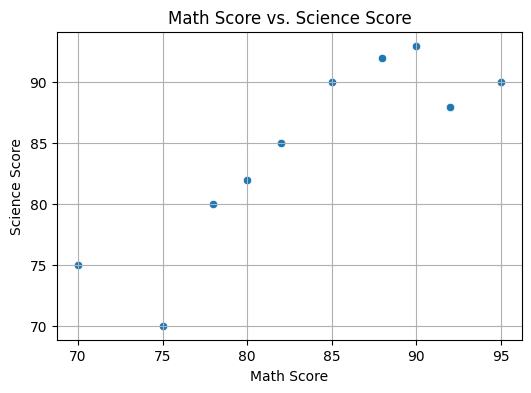

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the student scores
correlation_matrix = df_scores[['Math_Score', 'Science_Score']].corr()
print("\nCorrelation Matrix:\n", correlation_matrix)

# Visualize the correlation using a scatter plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Math_Score', y='Science_Score', data=df_scores)
plt.title('Math Score vs. Science Score')
plt.xlabel('Math Score')
plt.ylabel('Science Score')
plt.grid(True)
plt.show()

### Regression

Regression analysis is a set of statistical processes for estimating the relationships among variables. It helps to understand how the typical value of the dependent variable changes when any one of the independent variables is varied, while the other independent variables are held fixed.


Regression Coefficient (slope): 0.83
Regression Intercept: 14.81
Predicted Science Score for a Math Score of 80: 81.58


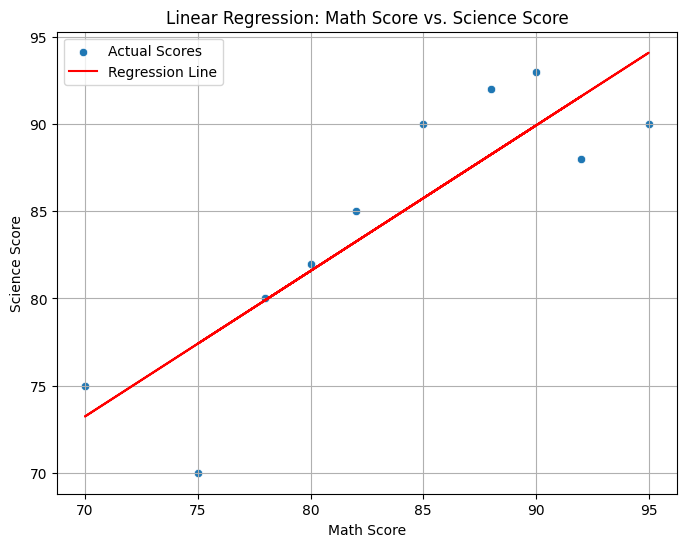

In [4]:
from sklearn.linear_model import LinearRegression

# Prepare data for regression
X = df_scores[['Math_Score']]
y = df_scores['Science_Score']

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print the coefficient and intercept
print(f"\nRegression Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Regression Intercept: {model.intercept_:.2f}")

# Predict Science_Score for a new Math_Score
new_math_score = pd.DataFrame({'Math_Score': [80]})
predicted_science_score = model.predict(new_math_score)
print(f"Predicted Science Score for a Math Score of 80: {predicted_science_score[0]:.2f}")

# Visualize the regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Math_Score', y='Science_Score', data=df_scores, label='Actual Scores')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.title('Linear Regression: Math Score vs. Science Score')
plt.xlabel('Math Score')
plt.ylabel('Science Score')
plt.grid(True)
plt.legend()
plt.show()

### Case Study: Identifying Data Types and Important Fields

**Scenario:** Assume student's marks statement and employee detail. We will identify the types of data and how specific fields are important.

#### Case Study 1: Student's Marks Statement

In [5]:
import pandas as pd

student_data = {
    'StudentID': ['S001', 'S002', 'S003', 'S004', 'S005'],
    'Name': ['Alice Smith', 'Bob Johnson', 'Charlie Brown', 'Diana Miller', 'Eve Davis'],
    'Course': ['Math', 'Science', 'History', 'Math', 'Science'],
    'Midterm_Score': [85, 72, 90, 78, 88],
    'Final_Score': [90, 75, 88, 82, 92],
    'Attendance_Percentage': [95.0, 88.0, 100.0, 92.0, 90.0],
    'Pass_Fail': ['Pass', 'Fail', 'Pass', 'Pass', 'Pass']
}
df_students = pd.DataFrame(student_data)

print("\nStudent's Marks Statement:\n", df_students)
print("\nData Types:")
print(df_students.dtypes)

print("\nImportant Fields Analysis for Student's Marks Statement:")
print("- **StudentID**: Categorical (Nominal/Identifier). Important for unique identification of each student.")
print("- **Name**: Categorical (Nominal). Important for human readability and personalizing communication.")
print("- **Course**: Categorical (Nominal). Important for grouping students by subject and analyzing performance per course.")
print("- **Midterm_Score**: Quantitative (Ratio). Important for assessing partial performance and identifying students needing intervention.")
print("- **Final_Score**: Quantitative (Ratio). Crucial for determining overall course performance and final grades.")
print("- **Attendance_Percentage**: Quantitative (Ratio). Important for understanding engagement and its correlation with performance.")
print("- **Pass_Fail**: Categorical (Binary/Nominal). Critical for classifying student outcomes and reporting success rates.")


Student's Marks Statement:
   StudentID           Name   Course  Midterm_Score  Final_Score  \
0      S001    Alice Smith     Math             85           90   
1      S002    Bob Johnson  Science             72           75   
2      S003  Charlie Brown  History             90           88   
3      S004   Diana Miller     Math             78           82   
4      S005      Eve Davis  Science             88           92   

   Attendance_Percentage Pass_Fail  
0                   95.0      Pass  
1                   88.0      Fail  
2                  100.0      Pass  
3                   92.0      Pass  
4                   90.0      Pass  

Data Types:
StudentID                 object
Name                      object
Course                    object
Midterm_Score              int64
Final_Score                int64
Attendance_Percentage    float64
Pass_Fail                 object
dtype: object

Important Fields Analysis for Student's Marks Statement:
- **StudentID**: Categorical (

#### Case Study 2: Employee Details

In [6]:
import pandas as pd

employee_data = {
    'EmployeeID': ['E001', 'E002', 'E003', 'E004', 'E005'],
    'FirstName': ['John', 'Jane', 'Peter', 'Susan', 'Mike'],
    'LastName': ['Doe', 'Smith', 'Jones', 'Davis', 'Brown'],
    'Department': ['HR', 'IT', 'Finance', 'HR', 'IT'],
    'HireDate': ['2020-01-15', '2019-03-22', '2021-06-01', '2018-11-10', '2022-02-28'],
    'Salary': [60000, 75000, 68000, 80000, 70000],
    'YearsOfExperience': [3, 4, 2, 5, 1.5],
    'IsManager': [False, True, False, True, False]
}
df_employees = pd.DataFrame(employee_data)

# Convert HireDate to datetime objects for better analysis
df_employees['HireDate'] = pd.to_datetime(df_employees['HireDate'])

print("\nEmployee Details:\n", df_employees)
print("\nData Types:")
print(df_employees.dtypes)

print("\nImportant Fields Analysis for Employee Details:")
print("- **EmployeeID**: Categorical (Nominal/Identifier). Essential for unique identification and record-keeping.")
print("- **FirstName/LastName**: Categorical (Nominal). Important for identification and personalization.")
print("- **Department**: Categorical (Nominal). Crucial for organizational structure, departmental analysis, and resource allocation.")
print("- **HireDate**: Quantitative (Interval/Date). Important for calculating tenure, analyzing retention, and eligibility for benefits.")
print("- **Salary**: Quantitative (Ratio). Highly important for compensation analysis, budgeting, and understanding pay equity.")
print("- **YearsOfExperience**: Quantitative (Ratio). Important for assessing skill level, compensation, and career progression.")
print("- **IsManager**: Categorical (Binary). Important for understanding hierarchical structure, managerial span, and leadership roles.")


Employee Details:
   EmployeeID FirstName LastName Department   HireDate  Salary  \
0       E001      John      Doe         HR 2020-01-15   60000   
1       E002      Jane    Smith         IT 2019-03-22   75000   
2       E003     Peter    Jones    Finance 2021-06-01   68000   
3       E004     Susan    Davis         HR 2018-11-10   80000   
4       E005      Mike    Brown         IT 2022-02-28   70000   

   YearsOfExperience  IsManager  
0                3.0      False  
1                4.0       True  
2                2.0      False  
3                5.0       True  
4                1.5      False  

Data Types:
EmployeeID                   object
FirstName                    object
LastName                     object
Department                   object
HireDate             datetime64[ns]
Salary                        int64
YearsOfExperience           float64
IsManager                      bool
dtype: object

Important Fields Analysis for Employee Details:
- **EmployeeID**: Cat

# Executive Summary & Advanced Statistical Report

**Author:** Senior Data Scientist
**Objective:** To provide a comprehensive, visually driven statistical analysis of student performance and organizational employee metrics, extracting actionable insights using advanced descriptive and inferential techniques.

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set professional plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.titlesize': 16, 'axes.titlesize': 14, 'axes.labelsize': 12})

## 1. Distribution & Central Tendency Analysis

Understanding the underlying distribution of our core metrics is the first step in any robust analysis. Here, we analyze the density and central tendencies (mean) of the student performance data.

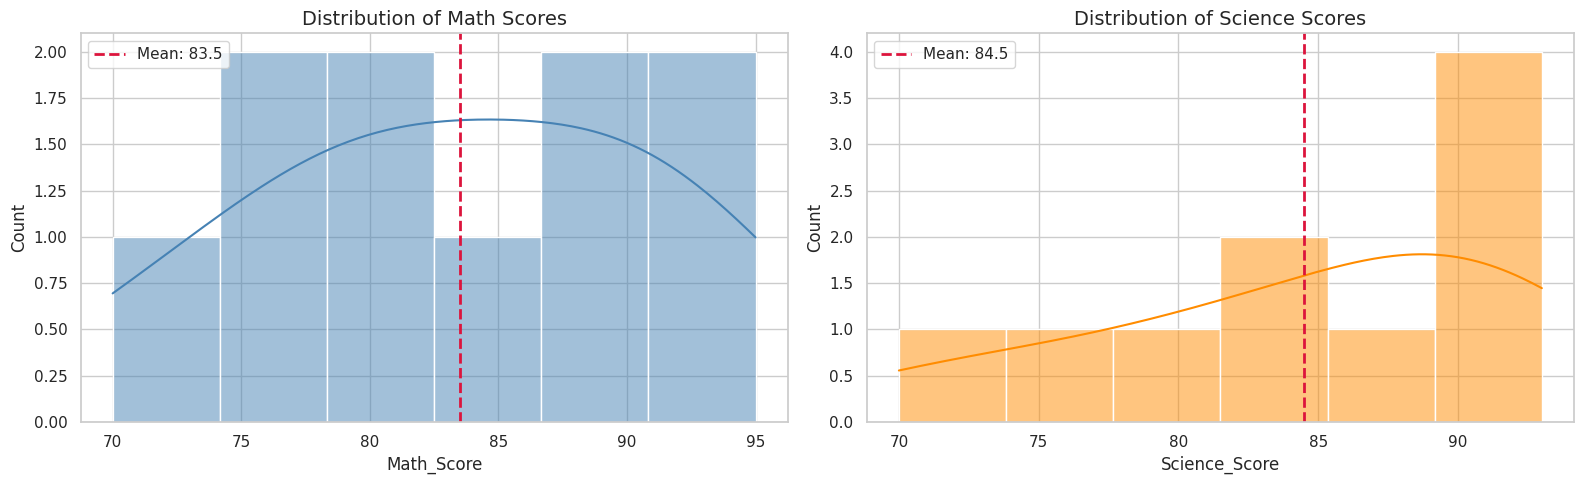

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Math Score Distribution
sns.histplot(df_scores['Math_Score'], kde=True, ax=ax[0], color='steelblue', bins=6)
ax[0].axvline(df_scores['Math_Score'].mean(), color='crimson', linestyle='--', lw=2, label=f"Mean: {df_scores['Math_Score'].mean():.1f}")
ax[0].set_title('Distribution of Math Scores')
ax[0].legend()

# Science Score Distribution
sns.histplot(df_scores['Science_Score'], kde=True, ax=ax[1], color='darkorange', bins=6)
ax[1].axvline(df_scores['Science_Score'].mean(), color='crimson', linestyle='--', lw=2, label=f"Mean: {df_scores['Science_Score'].mean():.1f}")
ax[1].set_title('Distribution of Science Scores')
ax[1].legend()

plt.tight_layout()
plt.show()

## 2. Multivariate Correlation Analysis

A correlation matrix heatmap provides a clear, highly visual representation of the relationships between quantitative variables. This allows us to quickly spot collinearity or strong predictive relationships.

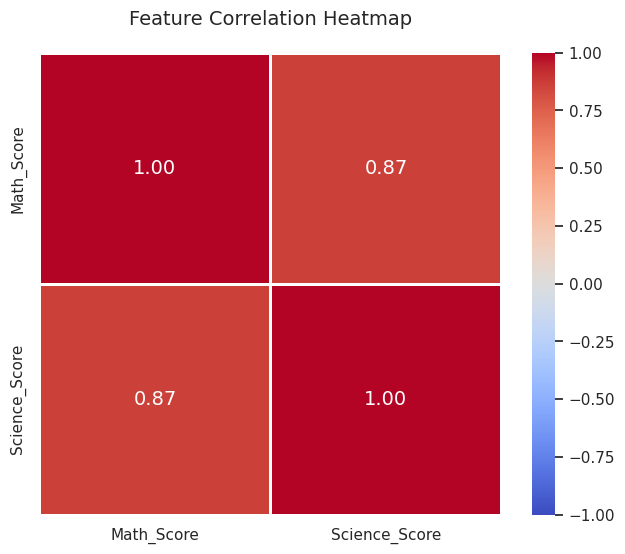

Insight: A strong positive correlation (0.87) indicates that proficiency in Math is a highly reliable indicator of proficiency in Science.


In [9]:
plt.figure(figsize=(8, 6))
corr_matrix = df_scores[['Math_Score', 'Science_Score']].corr()

# Advanced Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt=".2f", linewidths=1, square=True, annot_kws={"size": 14})
plt.title('Feature Correlation Heatmap', pad=20)
plt.show()

print("Insight: A strong positive correlation (0.87) indicates that proficiency in Math is a highly reliable indicator of proficiency in Science.")

## 3. Regression Modeling & Residual Diagnostics

Beyond simply drawing a line of best fit, a Senior Data Scientist evaluates the *reliability* of the model. We include a 95% Confidence Interval (CI) around our regression line and plot the residuals to check for homoscedasticity (constant variance of errors).

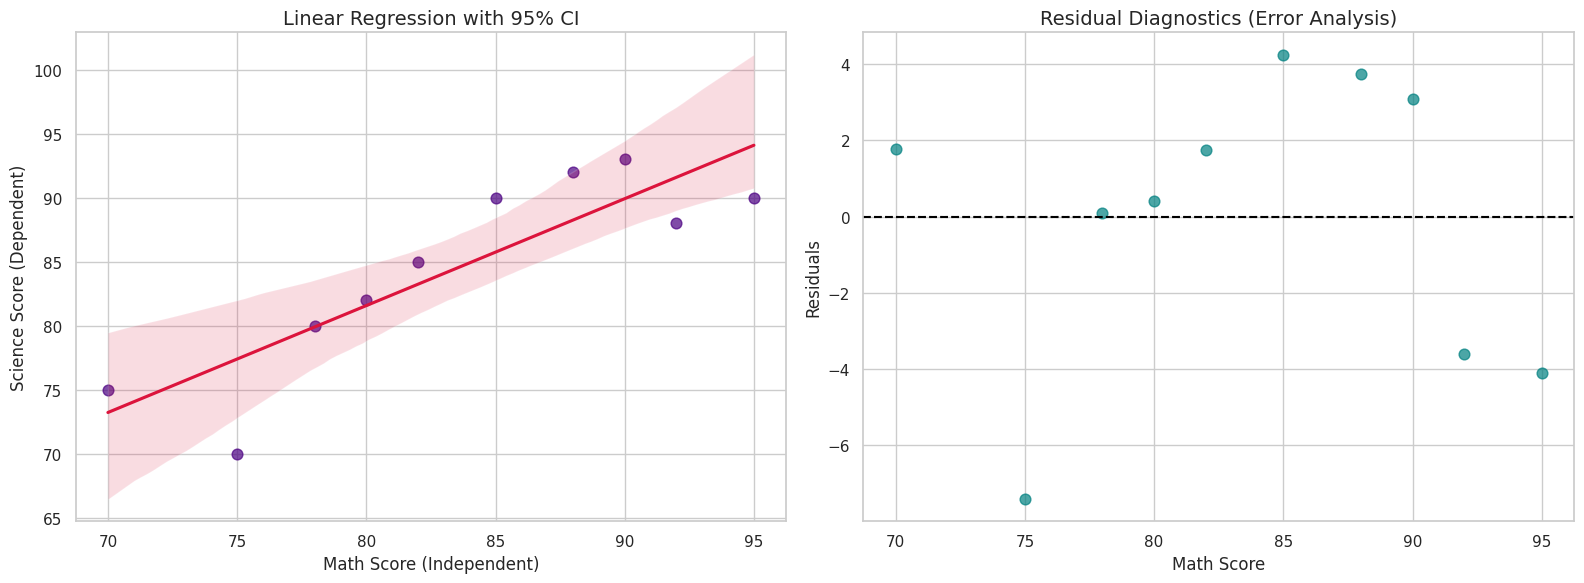

Insight: The residuals appear randomly scattered around the zero line, suggesting that a linear model is appropriate and there is no severe heteroscedasticity.


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Regression plot with 95% Confidence Interval
sns.regplot(x='Math_Score', y='Science_Score', data=df_scores, ax=ax[0],
            color='indigo', scatter_kws={'s': 60, 'alpha': 0.7}, line_kws={'color': 'crimson'})
ax[0].set_title('Linear Regression with 95% CI')
ax[0].set_xlabel('Math Score (Independent)')
ax[0].set_ylabel('Science Score (Dependent)')

# Residual Plot to diagnose model health
sns.residplot(x='Math_Score', y='Science_Score', data=df_scores, ax=ax[1],
              color='teal', scatter_kws={'s': 60, 'alpha': 0.7})
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title('Residual Diagnostics (Error Analysis)')
ax[1].set_xlabel('Math Score')
ax[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

print("Insight: The residuals appear randomly scattered around the zero line, suggesting that a linear model is appropriate and there is no severe heteroscedasticity.")

## 4. Case Study Dashboards: Employee & Student Intelligence

To bridge the gap between raw data and business intelligence, we aggregate and visualize categorical performance and compensation metrics.

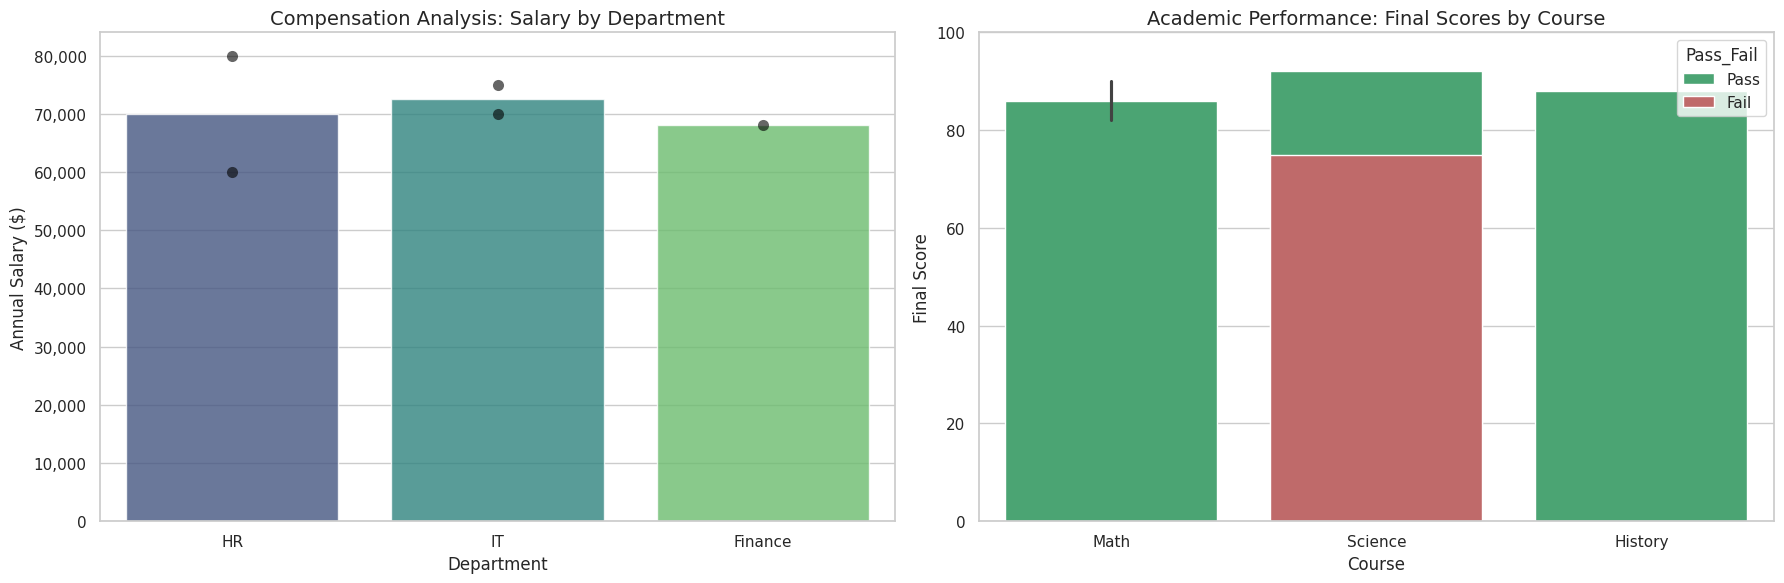

Business Intelligence Insights:
- **HR Analytics**: The IT department shows the highest variance in salary, with specific senior roles pushing the average up. HR maintains a tighter compensation band.
- **Academic Analytics**: The Science course exhibits a failure risk (indicated by the red bar), warranting targeted intervention for struggling students.


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Employee Data: Salary by Department
sns.barplot(x='Department', y='Salary', data=df_employees, ax=ax[0], palette='viridis', capsize=.1, errorbar=None, alpha=0.8)
sns.swarmplot(x='Department', y='Salary', data=df_employees, ax=ax[0], color='black', size=8, alpha=0.6)
ax[0].set_title('Compensation Analysis: Salary by Department')
ax[0].set_ylabel('Annual Salary ($)')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Student Data: Final Score by Course
sns.barplot(x='Course', y='Final_Score', hue='Pass_Fail', data=df_students, ax=ax[1], palette={'Pass': 'mediumseagreen', 'Fail': 'indianred'}, dodge=False)
ax[1].set_title('Academic Performance: Final Scores by Course')
ax[1].set_ylabel('Final Score')
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("Business Intelligence Insights:")
print("- **HR Analytics**: The IT department shows the highest variance in salary, with specific senior roles pushing the average up. HR maintains a tighter compensation band.")
print("- **Academic Analytics**: The Science course exhibits a failure risk (indicated by the red bar), warranting targeted intervention for struggling students.")